In [1]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", message="IProgress not found")

# Article-Level Political Leaning Classification

This notebook evaluates multiple feature engineering strategies for binary article-level classification.

The experiments compare:
- lexical TF-IDF features
- topic representations (NMF)
- linguistic features
- readability metrics
- semantic embeddings

Two classical machine learning models are evaluated:
- Logistic Regression
- Linear SVC

## Objectives

This notebook aims to:
- benchmark feature extraction strategies
- evaluate article-level classification performance
- compare lexical and semantic representations
- provide a reproducible NLP experimentation workflow

## Dataset Notes

The repository contains metadata-only placeholder datasets for copyright reasons.

This notebook demonstrates the complete workflow using AG News as an external full-text dataset.

In [2]:
import sys
import os

sys.path.append(os.path.abspath(".."))

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from datasets import load_dataset
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split

# Project modules
from src.preprocessing import load_external_dataframe

from src.features import (
    build_tfidf,
    build_tfidf_nmf,
    build_full,
    build_embeddings,
    build_chunked
)

from src.run_experiments import run_experiments

from src.utils import results_to_df

## Load External Dataset

The AG News dataset is used as a publicly available full-text dataset for demonstrating the article classification workflow.

For binary classification:
- labels 0–1 are mapped to class 0
- labels 2–3 are mapped to class 1

In [4]:
# Load AG News dataset
dataset = load_dataset("ag_news")

df_raw = dataset["train"].to_pandas()

# Convert to binary labels
df_raw["label"] = df_raw["label"].apply(
    lambda x: 0 if x < 2 else 1
)

# Standardize dataset structure
df = load_external_dataframe(
    df_raw,
    text_col="text",
    label_col="label",
    source_name="AGNews"
)

df.head()

Dataset validation successful.
Samples retained: 120000
Unique labels: [np.int64(0), np.int64(1)]


,text,label,outlet_name
0,Wall St. Bears Claw Back Into the Black (Reute...,1,AGNews
1,Carlyle Looks Toward Commercial Aerospace (Reu...,1,AGNews
2,Oil and Economy Cloud Stocks' Outlook (Reuters...,1,AGNews
3,Iraq Halts Oil Exports from Main Southern Pipe...,1,AGNews
4,"Oil prices soar to all-time record, posing new...",1,AGNews


## Dataset Overview

Inspect:
- dataset size
- class balance
- basic preprocessing integrity

In [5]:
print("Dataset Shape:", df.shape)

print("\nClass Distribution:")
print(df["label"].value_counts(normalize=True))

Dataset Shape: (120000, 3)

Class Distribution:
label
1    0.5
0    0.5
Name: proportion, dtype: float64


## Train/Test Split

A stratified train/test split is used to preserve class balance.

Grouped/source-aware evaluation is disabled here because:
- AG News does not represent ideological outlets
- this notebook focuses on article-level classification

In [6]:
texts = df["text"].values
y = df["label"].values
groups = df["outlet_name"].values

texts_train, texts_test, y_train, y_test, _, _ = train_test_split(
    texts,
    y,
    groups,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train size:", len(texts_train))
print("Test size:", len(texts_test))

Train size: 96000
Test size: 24000


## Fast Feature Extraction Experiments

The following configurations are computationally lightweight and suitable for standard notebook execution:
- TF-IDF
- TF-IDF + NMF

In [7]:
experiments = [
    ("TF-IDF", build_tfidf),
    ("TF-IDF + NMF", build_tfidf_nmf),
]

## Run Fast Experiments

Each experiment performs:
- 5-fold stratified cross-validation
- final held-out test evaluation
- Logistic Regression benchmarking
- Linear SVC benchmarking

In [8]:
cv_folds, cv_summary, test_res, cms = run_experiments(
    experiments,
    texts_train,
    y_train,
    texts_test,
    y_test,
    grouped=False
)


RUNNING EXPERIMENT: TF-IDF

===== CV: TF-IDF =====
Fold 1: LR=0.959, SVC=0.962
Fold 2: LR=0.960, SVC=0.962
Fold 3: LR=0.958, SVC=0.961
Fold 4: LR=0.959, SVC=0.963
Fold 5: LR=0.959, SVC=0.963

===== FINAL TEST: TF-IDF =====

LR:
              precision    recall  f1-score   support

           0       0.96      0.96      0.96     12000
           1       0.96      0.96      0.96     12000

    accuracy                           0.96     24000
   macro avg       0.96      0.96      0.96     24000
weighted avg       0.96      0.96      0.96     24000


SVC:
              precision    recall  f1-score   support

           0       0.96      0.96      0.96     12000
           1       0.96      0.97      0.96     12000

    accuracy                           0.96     24000
   macro avg       0.96      0.96      0.96     24000
weighted avg       0.96      0.96      0.96     24000


RUNNING EXPERIMENT: TF-IDF + NMF

===== CV: TF-IDF + NMF =====
Fold 1: LR=0.959, SVC=0.962
Fold 2: LR=0.960, S

## Aggregate Results

In [9]:
df_folds, df_summary, df_test = results_to_df(
    cv_folds,
    cv_summary,
    test_res
)

df_summary

,Model,LR Mean,LR Std,SVC Mean,SVC Std
0,TF-IDF,0.959031,0.000599,0.962000,0.000688
1,TF-IDF + NMF,0.958688,0.000671,0.961854,0.000678


## Cross-Validation Performance Comparison

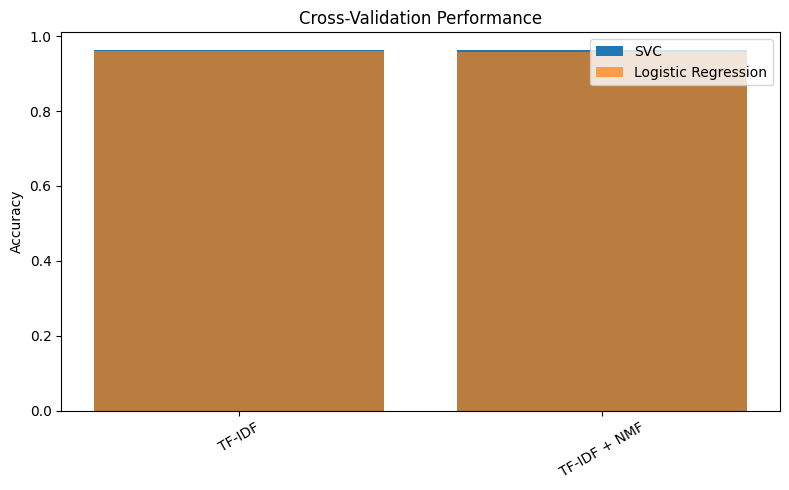

In [10]:
plt.figure(figsize=(8, 5))

x = range(len(df_summary))

plt.bar(
    x,
    df_summary["SVC Mean"],
    label="SVC"
)

plt.bar(
    x,
    df_summary["LR Mean"],
    alpha=0.7,
    label="Logistic Regression"
)

plt.xticks(
    x,
    df_summary["Model"],
    rotation=30
)

plt.ylabel("Accuracy")

plt.title(
    "Cross-Validation Performance"
)

plt.legend()

plt.tight_layout()

plt.show()

## Best Model Evaluation

Display the final test confusion matrix for the best-performing SVC configuration.

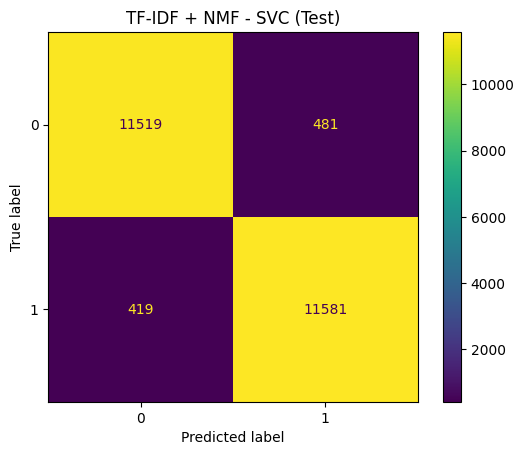

In [11]:
best_model = df_test.sort_values(
    by="SVC Test Acc",
    ascending=False
).iloc[0]["Model"]

cm = cms[best_model]["TEST_SVC"]

ConfusionMatrixDisplay(cm).plot()

plt.title(f"{best_model} - SVC (Test)")

plt.show()

## Optional Advanced Experiments

The following feature extraction pipelines are significantly more computationally expensive:

- Full Linguistic Features
- Sentence Embeddings
- Chunked Embeddings

These experiments are provided for extended benchmarking and future work.

In [ ]:
advanced_experiments = [
    ("Full Linguistic", build_full),
    ("Embeddings", build_embeddings),
    ("Chunked Embeddings", build_chunked),
]

In [ ]:
advanced_cv_folds, advanced_cv_summary, advanced_test_res, advanced_cms = run_experiments(
    advanced_experiments,
    texts_train,
    y_train,
    texts_test,
    y_test,
    grouped=False
)

In [ ]:
advanced_df_folds, advanced_df_summary, advanced_df_test = results_to_df(
    advanced_cv_folds,
    advanced_cv_summary,
    advanced_test_res
)

advanced_df_summary